# Retail Customer Behavior Analysis — Online Retail Dataset

This project analyzes a real UK-based online retail dataset to explore customer behavior 
across multiple dimensions: conversion funnel, cohort retention, churn, A/B testing, 
LTV, and market basket analysis.

**Dataset:** [UCI Online Retail](https://archive.ics.uci.edu/dataset/352/online+retail) 
— transactions from a UK gift shop between December 2010 and December 2011.

## 1. Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('seaborn-v0_8')
sns.set_palette('husl')

# Load data
df = pd.read_excel('../data/Online Retail.xlsx')

print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nFirst rows:")
df.head()

Shape: (541909, 8)

Columns: ['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'UnitPrice', 'CustomerID', 'Country']

First rows:


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


### Saving as CSV for faster reloading
Excel files are slow to parse. We save a clean copy as CSV for all subsequent work.

In [2]:
print("Shape:", df.shape)
print("Columns:", df.columns.tolist())
print("\nDate range:", df['InvoiceDate'].min(), "→", df['InvoiceDate'].max())
print("Unique customers:", df['CustomerID'].nunique())
print("Unique products:", df['StockCode'].nunique())
print("Countries:", df['Country'].nunique())

# Save as CSV for faster reloading
df.to_csv('../data/online_retail_raw.csv', index=False)
print("\nSaved as CSV.")

Shape: (541909, 8)
Columns: ['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'UnitPrice', 'CustomerID', 'Country']

Date range: 2010-12-01 08:26:00 → 2011-12-09 12:50:00
Unique customers: 4372
Unique products: 4070
Countries: 38

Saved as CSV.


## 2. Data Cleaning

Before any analysis, we need to understand and handle data quality issues:
- Missing CustomerIDs (transactions without identified customer)
- Cancelled orders (InvoiceNo starting with 'C')
- Negative quantities and zero/negative prices

In [3]:
print("=== NULL VALUES ===")
print(df.isnull().sum())

print("\n=== CANCELLED ORDERS ===")
cancelled = df[df['InvoiceNo'].astype(str).str.startswith('C')]
print(f"Cancelled transactions: {len(cancelled)} ({len(cancelled)/len(df)*100:.1f}%)")

print("\n=== NEGATIVE QUANTITIES ===")
print(f"Negative quantity rows: {(df['Quantity'] <= 0).sum()}")

print("\n=== ZERO/NEGATIVE PRICE ===")
print(f"Zero or negative price rows: {(df['UnitPrice'] <= 0).sum()}")

=== NULL VALUES ===
InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

=== CANCELLED ORDERS ===
Cancelled transactions: 9288 (1.7%)

=== NEGATIVE QUANTITIES ===
Negative quantity rows: 10624

=== ZERO/NEGATIVE PRICE ===
Zero or negative price rows: 2517


### Cleaning decisions
- **CustomerID nulls:** retained for product/revenue analysis — they represent 25% of transactions and contain valid sales data. Excluded only for customer-level analysis where individual identification is required.
- **Cancelled orders:** removed (InvoiceNo starting with 'C')
- **Negative quantities:** removed (returns already captured in cancellations)
- **Zero/negative prices:** removed (samples, adjustments, data entry errors)

In [4]:
# Clean dataset for customer-level analysis
df_clean = df[
    df['CustomerID'].notna() &
    ~df['InvoiceNo'].astype(str).str.startswith('C') &
    (df['Quantity'] > 0) &
    (df['UnitPrice'] > 0)
].copy()

df_clean['CustomerID'] = df_clean['CustomerID'].astype(int)
df_clean['TotalPrice'] = df_clean['Quantity'] * df_clean['UnitPrice']

print(f"Original: {len(df):,} rows")
print(f"Clean: {len(df_clean):,} rows")
print(f"Removed: {len(df)-len(df_clean):,} rows ({(len(df)-len(df_clean))/len(df)*100:.1f}%)")

Original: 541,909 rows
Clean: 397,884 rows
Removed: 144,025 rows (26.6%)


## 3. Exploratory Analysis — Key Business KPIs

Before diving into specific analyses, we calculate the core retail metrics that any BI dashboard would show: revenue, orders, average order value (AOV), and unique customers.

In [5]:
# Core KPIs
total_revenue = df_clean['TotalPrice'].sum()
total_orders = df_clean['InvoiceNo'].nunique()
total_customers = df_clean['CustomerID'].nunique()
aov = total_revenue / total_orders
avg_ltv = total_revenue / total_customers

print("=== CORE BUSINESS KPIs ===")
print(f"Total Revenue:       £{total_revenue:,.2f}")
print(f"Total Orders:        {total_orders:,}")
print(f"Unique Customers:    {total_customers:,}")
print(f"AOV (Avg Order Value): £{aov:,.2f}")
print(f"Avg Customer LTV:    £{avg_ltv:,.2f}")

=== CORE BUSINESS KPIs ===
Total Revenue:       £8,911,407.90
Total Orders:        18,532
Unique Customers:    4,338
AOV (Avg Order Value): £480.87
Avg Customer LTV:    £2,054.27


### Revenue Over Time
Monthly revenue trend to identify seasonality and growth patterns.

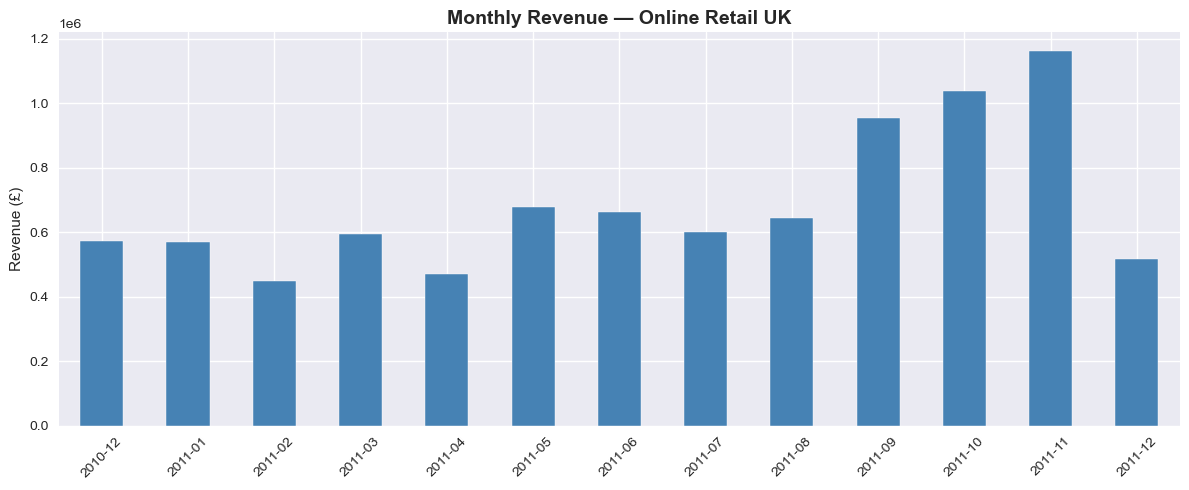

In [7]:
# Monthly revenue
df_clean['YearMonth'] = df_clean['InvoiceDate'].dt.to_period('M')
monthly_revenue = df_clean.groupby('YearMonth')['TotalPrice'].sum()

fig, ax = plt.subplots(figsize=(12, 5))
monthly_revenue.plot(kind='bar', ax=ax, color='steelblue', edgecolor='white')
ax.set_title('Monthly Revenue — Online Retail UK', fontsize=14, fontweight='bold')
ax.set_xlabel('')
ax.set_ylabel('Revenue (£)')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.savefig('../reports/monthly_revenue.png', dpi=150, bbox_inches='tight')
plt.show()

**Key insight:** Strong Q4 seasonality — revenue peaks in October–November driven by holiday gifting demand. November 2011 reached £1.16M, more than double the weakest month (February 2011 at £0.45M). December appears low due to incomplete data (only 9 days recorded).

### Top Products by Revenue and quantity Sold

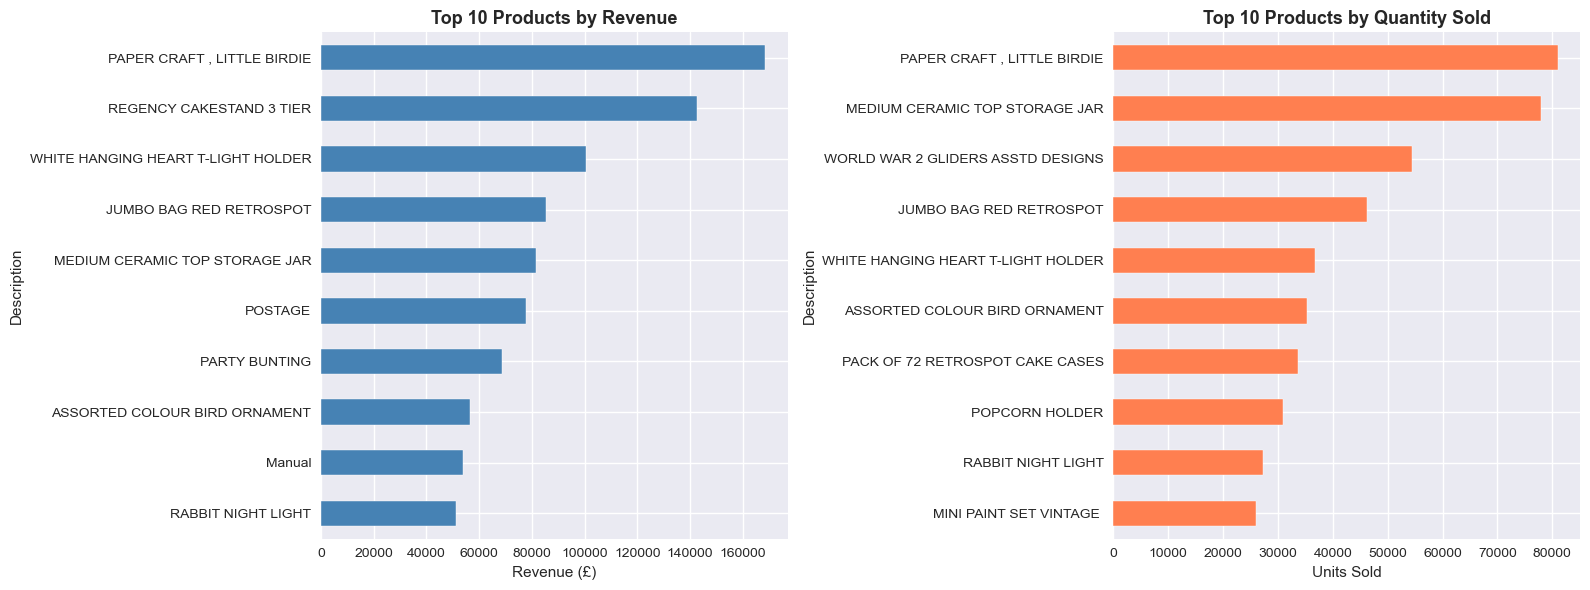

In [9]:
# Top 10 by revenue
top_by_revenue = df_clean.groupby('Description')['TotalPrice'].sum()\
    .sort_values(ascending=False).head(10)

# Top 10 by quantity sold
top_by_quantity = df_clean.groupby('Description')['Quantity'].sum()\
    .sort_values(ascending=False).head(10)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

top_by_revenue.plot(kind='barh', ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('Top 10 Products by Revenue', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Revenue (£)')
axes[0].invert_yaxis()

top_by_quantity.plot(kind='barh', ax=axes[1], color='coral', edgecolor='white')
axes[1].set_title('Top 10 Products by Quantity Sold', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Units Sold')
axes[1].invert_yaxis()

plt.tight_layout()
plt.savefig('../reports/top_products.png', dpi=150, bbox_inches='tight')
plt.show()

**Key insight:** "Paper Craft, Little Birdie" leads both in revenue and units sold — a clear hero product. Notably, "Postage" and "Manual" appear in the revenue chart but not in quantity, suggesting they are high-value non-product entries that should be filtered in deeper analysis.

### Revenue by Country

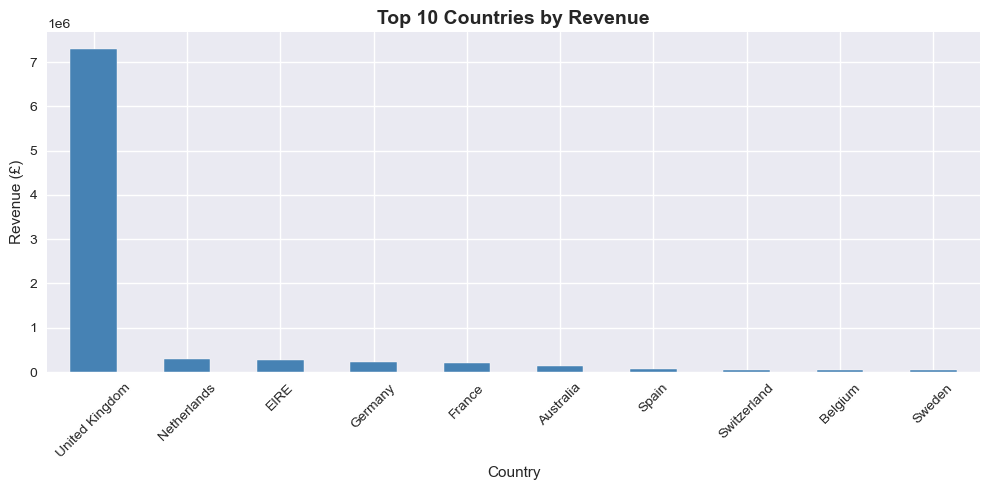

In [10]:
top_countries = df_clean.groupby('Country')['TotalPrice'].sum()\
    .sort_values(ascending=False).head(10)

fig, ax = plt.subplots(figsize=(10, 5))
top_countries.plot(kind='bar', ax=ax, color='steelblue', edgecolor='white')
ax.set_title('Top 10 Countries by Revenue', fontsize=14, fontweight='bold')
ax.set_ylabel('Revenue (£)')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.savefig('../reports/top_countries.png', dpi=150, bbox_inches='tight')
plt.show()

**Key insight:** The UK accounts for ~82% of total revenue, confirming this is primarily a domestic business. Netherlands and EIRE (Ireland) are the strongest international markets but still represent a small fraction of total sales.

## Summary

This notebook covered the foundational EDA for the Online Retail UK dataset:

- **541,909** raw transactions cleaned down to **397,884** valid records
- **£8.9M** total revenue across **4,338** unique customers over 12 months
- **AOV of £480** and average customer LTV of **£2,054** — consistent with a wholesale/B2B model
- Strong **Q4 seasonality** with November as peak month
- **"Paper Craft, Little Birdie"** is the hero product by both revenue and volume
- **82% of revenue** comes from the UK market

Next notebooks will dive into cohort analysis, churn, A/B testing, and market basket analysis.